In [1]:
# Loading the dataset

In [2]:
import pandas as pd
file_path = r"C:\Users\USER\OneDrive\Desktop\My_Docs\Data Analyst_Business Analyst Projects\Financial Transaction Risk & Fraud Pattern Analysis\paysim_transactions.csv"
df = pd.read_csv(file_path)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print(df.head())

Rows: 6362620
Columns: 11
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [4]:
df.shape

(6362620, 11)

In [ ]:
# Basic profiling

In [5]:
df.describe

<bound method NDFrame.describe of          step      type      amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT     9839.64  C1231006815      170136.00   
1           1   PAYMENT     1864.28  C1666544295       21249.00   
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
4           1   PAYMENT    11668.14  C2048537720       41554.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0             160296.36  M1979787155            0.00            0.00        0   

In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
df['type'].value_counts()

CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: type, dtype: int64

In [8]:
df['isFraud'].value_counts()

0    6354407
1       8213
Name: isFraud, dtype: int64

In [10]:
## Overall Fraud Exposure

# Calculate the key metrics

In [11]:
total_transactions = len(df)

fraudulent_transactions = (df["isFraud"] == 1).sum()

non_fraudulent_transactions = (df["isFraud"] == 0).sum()

fraud_rate = (
    fraudulent_transactions / total_transactions
) * 100

total_transaction_value = df["amount"].sum()

fraud_value = df.loc[df["isFraud"] == 1, "amount"].sum()

avg_fraud_amount = df.loc[
    df["isFraud"] == 1, "amount"
].mean()

fraud_value_percentage = (
    fraud_value / total_transaction_value
) * 100

print(f"Total transactions: {total_transactions:,}")
print(f"Fraudulent transactions: {fraudulent_transactions:,}")
print(f"Non-fraudulent transactions: {non_fraudulent_transactions:,}")
print(f"Fraud rate: {fraud_rate:.4f}%")
print(f"Total transaction value: {total_transaction_value:,.2f}")
print(f"Fraud value: {fraud_value:,.2f}")
print(f"Average fraud amount: {avg_fraud_amount:,.2f}")
print(f"Fraud value percentage: {fraud_value_percentage:.4f}%")

Total transactions: 6,362,620
Fraudulent transactions: 8,213
Non-fraudulent transactions: 6,354,407
Fraud rate: 0.1291%
Total transaction value: 1,144,392,944,759.77
Fraud value: 12,056,415,427.84
Average fraud amount: 1,467,967.30
Fraud value percentage: 1.0535%


In [15]:
# KPIs into a DataFrame

fraud_kpis = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Fraudulent Transactions",
        "Non-Fraudulent Transactions",
        "Fraud Rate (%)",
        "Total Transaction Value",
        "Fraud Value",
        "Average Fraud Amount",
        "Fraud Value (%)"
    ],
    "Value": [
        total_transactions,
        fraudulent_transactions,
        non_fraudulent_transactions,
        fraud_rate,
        total_transaction_value,
        fraud_value,
        avg_fraud_amount,
        fraud_value_percentage
    ]
})

fraud_kpis

,Metric,Value
0,Total Transactions,6.362620e+06
1,Fraudulent Transactions,8.213000e+03
2,Non-Fraudulent Transactions,6.354407e+06
3,Fraud Rate (%),1.290820e-01
4,Total Transaction Value,1.144393e+12
5,Fraud Value,1.205642e+10
6,Average Fraud Amount,1.467967e+06
7,Fraud Value (%),1.053521e+00


In [16]:
fraud_kpis_formatted = fraud_kpis.copy()

fraud_kpis_formatted["Value"] = fraud_kpis_formatted.apply(
    lambda row: (
        f"{row['Value']:,.4f}"
        if "(%)" in row["Metric"]
        else f"{row['Value']:,.2f}"
    ),
    axis=1
)

fraud_kpis_formatted

,Metric,Value
0,Total Transactions,"6,362,620.00"
1,Fraudulent Transactions,"8,213.00"
2,Non-Fraudulent Transactions,"6,354,407.00"
3,Fraud Rate (%),0.1291
4,Total Transaction Value,"1,144,392,944,759.77"
5,Fraud Value,"12,056,415,427.84"
6,Average Fraud Amount,"1,467,967.30"
7,Fraud Value (%),1.0535


In [17]:
# Fraud by Transaction Type

type_analysis = (
    df.groupby("type")
      .agg(
          total_transactions=("type", "size"),
          fraudulent_transactions=("isFraud", "sum"),
          total_transaction_value=("amount", "sum"),
          fraud_value=("amount", lambda x: x[df.loc[x.index, "isFraud"] == 1].sum())
      )
      .reset_index()
)

type_analysis["fraud_rate"] = (
    type_analysis["fraudulent_transactions"]
    / type_analysis["total_transactions"]
) * 100

type_analysis["fraud_value_percentage"] = (
    type_analysis["fraud_value"]
    / type_analysis["total_transaction_value"]
) * 100

type_analysis = type_analysis.sort_values(
    "fraud_rate",
    ascending=False
)

type_analysis

,type,total_transactions,fraudulent_transactions,total_transaction_value,fraud_value,fraud_rate,fraud_value_percentage
4,TRANSFER,532909,4097,4.852920e+11,6.067213e+09,0.768799,1.250219
1,CASH_OUT,2237500,4116,3.944130e+11,5.989202e+09,0.183955,1.518510
0,CASH_IN,1399284,0,2.363674e+11,0.000000e+00,0.000000,0.000000
2,DEBIT,41432,0,2.271992e+08,0.000000e+00,0.000000,0.000000
3,PAYMENT,2151495,0,2.809337e+10,0.000000e+00,0.000000,0.000000


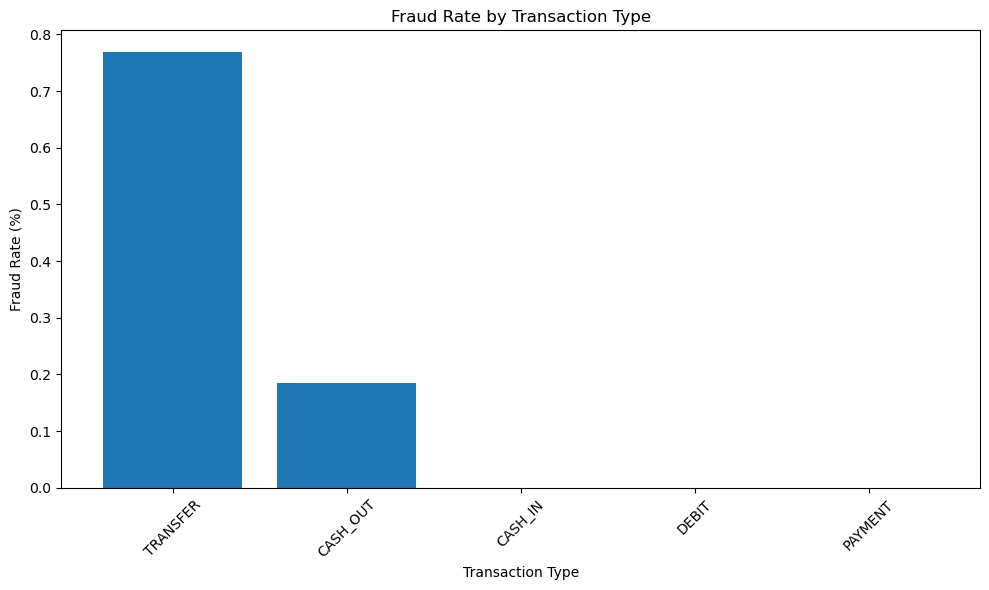

In [18]:
# Visualize fraud rate

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    type_analysis["type"],
    type_analysis["fraud_rate"]
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

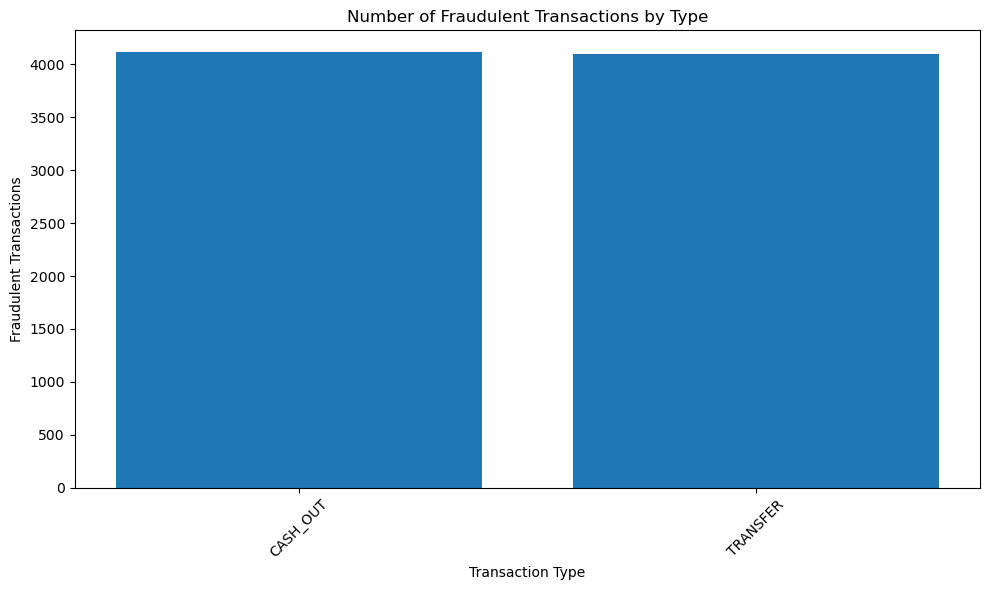

In [19]:
# Fraud count

fraud_count_by_type = (
    df[df["isFraud"] == 1]
    .groupby("type")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    fraud_count_by_type.index,
    fraud_count_by_type.values
)

plt.title("Number of Fraudulent Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraudulent Transactions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

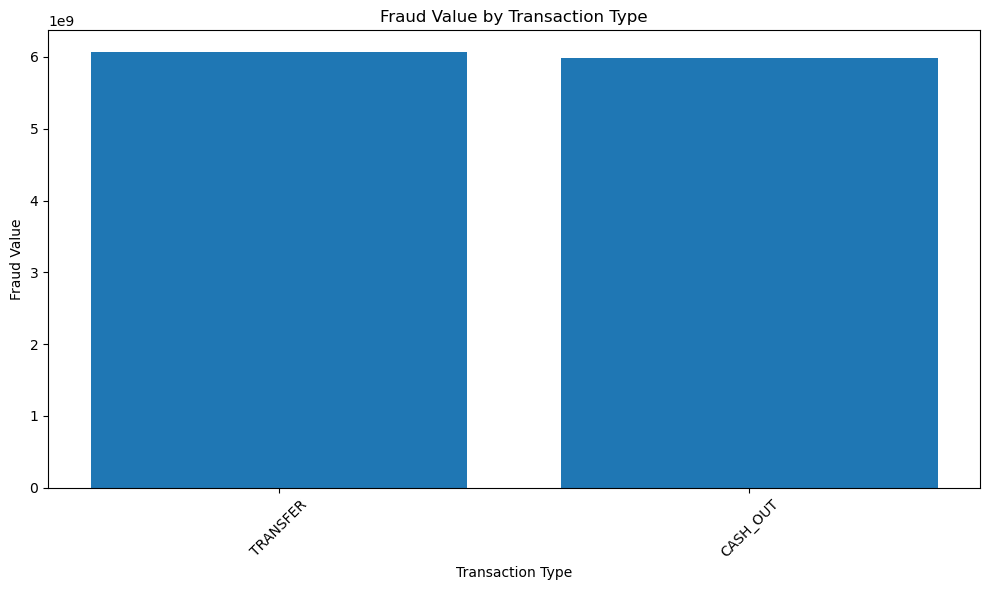

In [20]:
# Fraud value

fraud_value_by_type = (
    df[df["isFraud"] == 1]
    .groupby("type")["amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    fraud_value_by_type.index,
    fraud_value_by_type.values
)

plt.title("Fraud Value by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [21]:
# Fraud by Transaction Amount
df["amount_band"] = pd.cut(
    df["amount"],
    bins=[-1, 1000, 10000, 50000, 100000, 200000, float("inf")],
    labels=[
        "< 1K",
        "1K - 10K",
        "10K - 50K",
        "50K - 100K",
        "100K - 200K",
        "200K+"
    ]
)

In [22]:
amount_analysis = (
    df.groupby("amount_band", observed=True)
      .agg(
          total_transactions=("amount", "size"),
          fraudulent_transactions=("isFraud", "sum"),
          total_transaction_value=("amount", "sum"),
          fraud_value=("amount", lambda x: x[df.loc[x.index, "isFraud"] == 1].sum())
      )
      .reset_index()
)

amount_analysis["fraud_rate"] = (
    amount_analysis["fraudulent_transactions"]
    / amount_analysis["total_transactions"]
) * 100

amount_analysis["fraud_value_percentage"] = (
    amount_analysis["fraud_value"]
    / amount_analysis["total_transaction_value"]
) * 100

amount_analysis

,amount_band,total_transactions,fraudulent_transactions,total_transaction_value,fraud_value,fraud_rate,fraud_value_percentage
0,< 1K,142646,58,7.156829e+07,1.403918e+04,0.040660,0.019616
1,1K - 10K,1143445,220,5.974702e+09,1.187787e+06,0.019240,0.019880
2,10K - 50K,1519856,760,3.611900e+10,2.238543e+07,0.050005,0.061977
3,50K - 100K,719351,669,5.334745e+10,4.943280e+07,0.093000,0.092662
4,100K - 200K,1163752,1035,1.714990e+11,1.498528e+08,0.088936,0.087378
5,200K+,1673570,5471,8.773812e+11,1.183354e+10,0.326906,1.348734


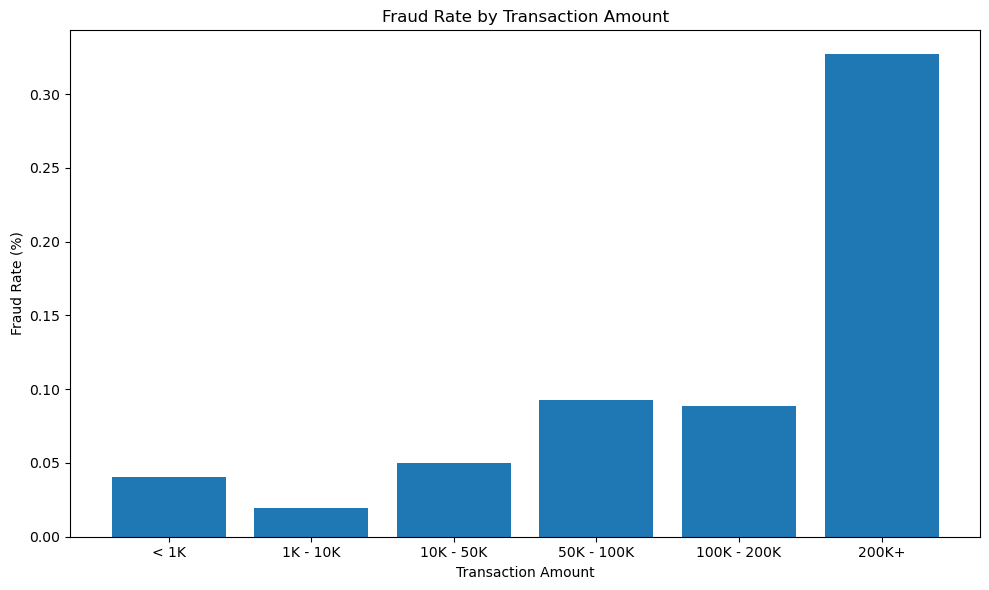

In [23]:
# Fraud rate by amount

plt.figure(figsize=(10, 6))

plt.bar(
    amount_analysis["amount_band"],
    amount_analysis["fraud_rate"]
)

plt.title("Fraud Rate by Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

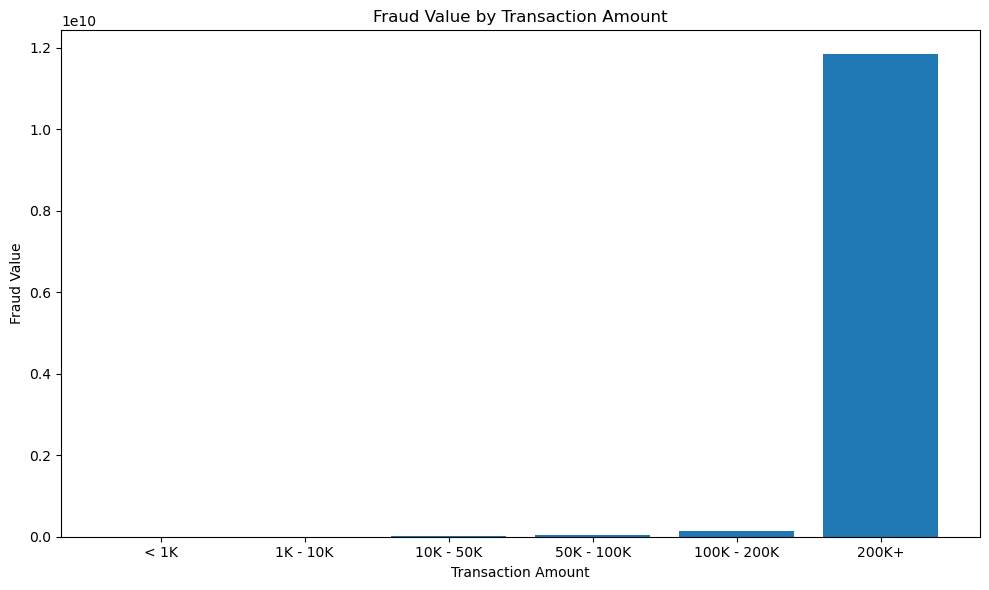

In [24]:
# Fraud value by amount band

plt.figure(figsize=(10, 6))

plt.bar(
    amount_analysis["amount_band"],
    amount_analysis["fraud_value"]
)

plt.title("Fraud Value by Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Fraud Value")

plt.tight_layout()
plt.show()